<a href="https://colab.research.google.com/github/laurenGoodrich/ETLPipeline/blob/main/Lauren_Goodrich_Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Goal of the project:
##101 artists top 10 songs compared to billboard appearances based on the release date of the song

link to billboard chart data: https://www.billboard.com/charts/
link to spotify: https://open.spotify.com/
(URIs for each artist were also provided, and Spotify's API was used)


##Start by collecting data from Spotify API

In [ ]:
#Mount drive
import os, sys
from google.colab import drive
drive.mount('/content/mnt')
nb_path = '/content/notebooks'
os.symlink('/content/mnt/My Drive/Colab Notebooks', nb_path)
sys.path.insert(0, nb_path)  # or append(nb_path)

In [ ]:
# Install only once. Tomorrow, you can skip this.
!pip install --target=$nb_path spotipy

  Using cached spotipy-2.23.0-py3-none-any.whl (29 kB)
  Using cached redis-5.0.4-py3-none-any.whl (251 kB)
  Using cached requests-2.31.0-py3-none-any.whl (62 kB)
  Using cached six-1.16.0-py2.py3-none-any.whl (11 kB)
  Using cached urllib3-2.2.1-py3-none-any.whl (121 kB)
  Using cached async_timeout-4.0.3-py3-none-any.whl (5.7 kB)
  Using cached charset_normalizer-3.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (142 kB)
  Using cached idna-3.7-py3-none-any.whl (66 kB)
  Using cached certifi-2024.2.2-py3-none-any.whl (163 kB)
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/pip/_vendor/pkg_resources/__init__.py", line 3108, in _dep_map
    return self.__dep_map
  File "/usr/local/lib/python3.10/dist-packages/pip/_vendor/pkg_resources/__init__.py", line 2901, in __getattr__
    raise AttributeError(attr)
AttributeError: _DistInfoDistribution__dep_map

During handling of the above exception, another ex

In [ ]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

spotify_client_id = 'cd88a715bb7e41d0bf2db12279723357'
spotify_client_secret  = '85ed1e1b343b4396ba12bab90b5608e2'

client_credentials_manager = SpotifyClientCredentials(
    client_id=spotify_client_id,
    client_secret=spotify_client_secret
)

sp = spotipy.Spotify(
    client_credentials_manager=client_credentials_manager
)

In [ ]:
#Libraries
import pandas as pd
import numpy as np

Get Beyonce's URI. Link to data: https://open.spotify.com/artist/6vWDO969PvNqNYHIOW5v0
URI: spotify:artist:6vWDO969PvNqNYHIOW5v0m

In [ ]:

beyonce_art = sp.artist('spotify:artist:6vWDO969PvNqNYHIOW5v0m')

Start by exploring the artist's data

In [ ]:
# Check it out
beyonce_art

{'external_urls': {'spotify': 'https://open.spotify.com/artist/6vWDO969PvNqNYHIOW5v0m'},
 'followers': {'href': None, 'total': 37213771},
 'genres': ['pop', 'r&b'],
 'href': 'https://api.spotify.com/v1/artists/6vWDO969PvNqNYHIOW5v0m',
 'id': '6vWDO969PvNqNYHIOW5v0m',
 'images': [{'height': 640,
   'url': 'https://i.scdn.co/image/ab6761610000e5eb247f44069c0bd1781df2f785',
   'width': 640},
  {'height': 320,
   'url': 'https://i.scdn.co/image/ab67616100005174247f44069c0bd1781df2f785',
   'width': 320},
  {'height': 160,
   'url': 'https://i.scdn.co/image/ab6761610000f178247f44069c0bd1781df2f785',
   'width': 160}],
 'name': 'Beyoncé',
 'popularity': 88,
 'type': 'artist',
 'uri': 'spotify:artist:6vWDO969PvNqNYHIOW5v0m'}

In [ ]:
beyonce_art.keys()

dict_keys(['external_urls', 'followers', 'genres', 'href', 'id', 'images', 'name', 'popularity', 'type', 'uri'])

In [ ]:
#This function will take an artist ID and then store the name, id, followers, and genre, and then add them all into a list.

def get_artist_info(art_id): # define name and argument
  art_json = sp.artist(art_id) # calling out to the spotipy function using the art_id that was given
  artist_name = art_json['name'] # use that json object to get name
  artist_id = art_json['id'] # artist id
  followers = art_json['followers']['total'] #down a level in followers to get total number
  popularity = art_json['popularity']
  genre = art_json['genres'][0] #extracting just the first genre in the list
  art_list = [artist_name, artist_id, followers, popularity, genre] # make a list
  return(art_list) # have your function return that list



In [ ]:
beyonce_art_list = get_artist_info('6vWDO969PvNqNYHIOW5v0m')
beyonce_art_list

['Beyoncé', '6vWDO969PvNqNYHIOW5v0m', 37213771, 88, 'pop']

In [ ]:
# Now we can turn that list into a dataframe using pd.DataFrame()
# You need to provide the list and then a list of column names
# We'll store this as 'artist_info'
artist_info = pd.DataFrame(data = [beyonce_art_list], columns = ['artist_name', 'artist_id', 'followers', 'popularity', 'genre'])
artist_info

,artist_name,artist_id,followers,popularity,genre
0,Beyoncé,6vWDO969PvNqNYHIOW5v0m,37213771,88,pop


Now I want to look at the top 10 tracks for this artist.

In [ ]:
# Assign top 10 songs to artist_top
artist_top = sp.artist_top_tracks(artist_info['artist_id'][0])
artist_top

{'tracks': [{'album': {'album_type': 'album',
    'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/6vWDO969PvNqNYHIOW5v0m'},
      'href': 'https://api.spotify.com/v1/artists/6vWDO969PvNqNYHIOW5v0m',
      'id': '6vWDO969PvNqNYHIOW5v0m',
      'name': 'Beyoncé',
      'type': 'artist',
      'uri': 'spotify:artist:6vWDO969PvNqNYHIOW5v0m'}],
    'external_urls': {'spotify': 'https://open.spotify.com/album/6BzxX6zkDsYKFJ04ziU5xQ'},
    'href': 'https://api.spotify.com/v1/albums/6BzxX6zkDsYKFJ04ziU5xQ',
    'id': '6BzxX6zkDsYKFJ04ziU5xQ',
    'images': [{'height': 640,
      'url': 'https://i.scdn.co/image/ab67616d0000b2731572698fff8a1db257a53599',
      'width': 640},
     {'height': 300,
      'url': 'https://i.scdn.co/image/ab67616d00001e021572698fff8a1db257a53599',
      'width': 300},
     {'height': 64,
      'url': 'https://i.scdn.co/image/ab67616d000048511572698fff8a1db257a53599',
      'width': 64}],
    'is_playable': True,
    'name': 'COWBOY CARTER',


In [ ]:
# The topmost key is 'tracks' which makes sense as it's 10 indivdiual tracks
artist_top.keys()

dict_keys(['tracks'])

In [ ]:
# Let's call it on artist_top['tracks']
# Add .head(3) just to see only the first few.
pd.json_normalize(artist_top['tracks']).head(3)

,artists,disc_number,duration_ms,explicit,href,id,is_local,is_playable,name,popularity,...,album.images,album.is_playable,album.name,album.release_date,album.release_date_precision,album.total_tracks,album.type,album.uri,external_ids.isrc,external_urls.spotify
0,[{'external_urls': {'spotify': 'https://open.s...,1,233456,True,https://api.spotify.com/v1/tracks/7wLShogStyDe...,7wLShogStyDeZvL0a6daN5,False,True,TEXAS HOLD 'EM,87,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,COWBOY CARTER,2024-03-29,day,27,album,spotify:album:6BzxX6zkDsYKFJ04ziU5xQ,USSM12401302,https://open.spotify.com/track/7wLShogStyDeZvL...
1,[{'external_urls': {'spotify': 'https://open.s...,1,208521,False,https://api.spotify.com/v1/tracks/6zuPQl2RVqQ4...,6zuPQl2RVqQ4y5nAH61CFC,False,True,II MOST WANTED,76,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,COWBOY CARTER,2024-03-27,day,27,album,spotify:album:2m1enA3YrMLVvR3q0MqLpL,USSM12402717,https://open.spotify.com/track/6zuPQl2RVqQ4y5n...
2,[{'external_urls': {'spotify': 'https://open.s...,1,236133,False,https://api.spotify.com/v1/tracks/5IVuqXILoxVW...,5IVuqXILoxVWvWEPm82Jxr,False,True,Crazy In Love (feat. Jay-Z),80,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Dangerously In Love,2003-06-24,day,15,album,spotify:album:6oxVabMIqCMJRYN1GqR3Vf,USSM10305425,https://open.spotify.com/track/5IVuqXILoxVWvWE...


In [ ]:
pd.json_normalize(artist_top['tracks'],
  record_path=['artists'],
  meta = ['id', 'name'],
  record_prefix = 'artist_',
  meta_prefix = 'track_',
  sep = '_').head(3)

,artist_href,artist_id,artist_name,artist_type,artist_uri,artist_external_urls_spotify,track_id,track_name
0,https://api.spotify.com/v1/artists/6vWDO969PvN...,6vWDO969PvNqNYHIOW5v0m,Beyoncé,artist,spotify:artist:6vWDO969PvNqNYHIOW5v0m,https://open.spotify.com/artist/6vWDO969PvNqNY...,7wLShogStyDeZvL0a6daN5,TEXAS HOLD 'EM
1,https://api.spotify.com/v1/artists/6vWDO969PvN...,6vWDO969PvNqNYHIOW5v0m,Beyoncé,artist,spotify:artist:6vWDO969PvNqNYHIOW5v0m,https://open.spotify.com/artist/6vWDO969PvNqNY...,6zuPQl2RVqQ4y5nAH61CFC,II MOST WANTED
2,https://api.spotify.com/v1/artists/5YGY8feqx7n...,5YGY8feqx7naU7z4HrwZM6,Miley Cyrus,artist,spotify:artist:5YGY8feqx7naU7z4HrwZM6,https://open.spotify.com/artist/5YGY8feqx7naU7...,6zuPQl2RVqQ4y5nAH61CFC,II MOST WANTED


In [ ]:
# Lets store our data this time as top_track_info
top_track_info = pd.json_normalize(artist_top['tracks'],
                                   record_path=['artists'],
                                   meta=['id', 'name', ['album', 'release_date']],
                                   record_prefix='artist_',
                                   meta_prefix='track_',
                                   sep='_')

top_track_info.head()

Make sure to extract the release date because that will be used to compare to the billboard chart at the time of that release.

In [ ]:
# Apply the function to each track and add a new column for release date
top_track_info = top_track_info[['artist_name', 'artist_id', 'track_id', 'track_name', 'track_album_release_date']]
top_track_info.head()

,artist_name,artist_id,track_id,track_name,track_album_release_date
0,Beyoncé,6vWDO969PvNqNYHIOW5v0m,7wLShogStyDeZvL0a6daN5,TEXAS HOLD 'EM,2024-03-29
1,Beyoncé,6vWDO969PvNqNYHIOW5v0m,6zuPQl2RVqQ4y5nAH61CFC,II MOST WANTED,2024-03-27
2,Miley Cyrus,5YGY8feqx7naU7z4HrwZM6,6zuPQl2RVqQ4y5nAH61CFC,II MOST WANTED,2024-03-27
3,Beyoncé,6vWDO969PvNqNYHIOW5v0m,5IVuqXILoxVWvWEPm82Jxr,Crazy In Love (feat. Jay-Z),2003-06-24
4,JAY-Z,3nFkdlSjzX9mRTtwJOzDYB,5IVuqXILoxVWvWEPm82Jxr,Crazy In Love (feat. Jay-Z),2003-06-24


In [ ]:
# I'm going to filter our dataframe and use the .isin() function.
# This is asking if a level in artist_name from top_track_info is ever seen in the artist_name column in our earlier artist_info dataframe.
print('before: ' +  ', '.join(top_track_info['artist_name'].unique())) # before
top_track_info = top_track_info[top_track_info['artist_name'].isin(artist_info['artist_name'])]

# check to verify!
print('after: ' +  ', '.join(top_track_info['artist_name'].unique())) # after

before: Beyoncé, Miley Cyrus, JAY-Z, Post Malone, Linda Martell, Shaboozey
after: Beyoncé


Now I will join the artist_info table with the top_track_info table. This is what we will be doing with the larger list of artists, but we will start with one so it is easier to explore the data.

In [ ]:
# A reminder of what's in artist_info
artist_info

,artist_name,artist_id,followers,popularity,genre
0,Beyoncé,6vWDO969PvNqNYHIOW5v0m,37213771,88,pop


In [ ]:
# Join artist info.  The key in this case is artist_id
top_track_info.merge(artist_info, left_on = 'artist_id', right_on= 'artist_id', how = 'left')

,artist_name_x,artist_id,track_id,track_name,track_album_release_date,artist_name_y,followers,popularity,genre
0,Beyoncé,6vWDO969PvNqNYHIOW5v0m,7wLShogStyDeZvL0a6daN5,TEXAS HOLD 'EM,2024-03-29,Beyoncé,37213771,88,pop
1,Beyoncé,6vWDO969PvNqNYHIOW5v0m,6zuPQl2RVqQ4y5nAH61CFC,II MOST WANTED,2024-03-27,Beyoncé,37213771,88,pop
2,Beyoncé,6vWDO969PvNqNYHIOW5v0m,5IVuqXILoxVWvWEPm82Jxr,Crazy In Love (feat. Jay-Z),2003-06-24,Beyoncé,37213771,88,pop
3,Beyoncé,6vWDO969PvNqNYHIOW5v0m,1VxEaXbIq3xAvqh80xP67w,JOLENE,2024-03-27,Beyoncé,37213771,88,pop
4,Beyoncé,6vWDO969PvNqNYHIOW5v0m,6Y4rniIxibegzsg8cdWAWV,BODYGUARD,2024-03-29,Beyoncé,37213771,88,pop
5,Beyoncé,6vWDO969PvNqNYHIOW5v0m,2UDARQiksl207HcSduDpov,LEVII'S JEANS,2024-03-29,Beyoncé,37213771,88,pop
6,Beyoncé,6vWDO969PvNqNYHIOW5v0m,7x5ziCOQFir0AQN8dFisK6,16 CARRIAGES,2024-03-27,Beyoncé,37213771,88,pop
7,Beyoncé,6vWDO969PvNqNYHIOW5v0m,3ERa3mEeOnrh2Mc47qM6T1,Halo,2008-11-14,Beyoncé,37213771,88,pop
8,Beyoncé,6vWDO969PvNqNYHIOW5v0m,0K9tfzrxJyCQIf7oAlPwaK,YA YA,2024-03-29,Beyoncé,37213771,88,pop
9,Beyoncé,6vWDO969PvNqNYHIOW5v0m,5UcUppRaEIBMIHXiUFl7LI,SPAGHETTII,2024-03-29,Beyoncé,37213771,88,pop


Now I am going to do this with a list of 100 artists. Here is the list of artists: 100
Frank Sinatra, Dance With the Dead, Fall Out Boy, Patrick Topping, Amelie Lens, SZA, Bad Bunny, Janelle Monáe keshi, NELL, Silly Silky, Sik-K, Billie Eilish, Zedd, Tièsto, Andrea Bocelli, Flume, Todd Terie, Khalid, Drake, AC/DC, Coldplay, Green Day, I Prevail, Rag'n'Bone Man, Mark Knopfler deadmau5, Darren Korb, Tobu, Khruangbin, Steve Lacy, Tom Misch, J. Cole, Lil Uzi Vert,Archspire, Beyonce, Frank Ocean, Taylor Swift, Lana Del Rey, Hozier, Childish Gambino, Kendrick Lamar, Rihanna, Ms. Lauryn Hill, Noah Kahn, Olivia Rodrigo, One Direction, Harry Styles, Daniel Ceasar, Jack Johnson, Adele, Future, Ariana Grande, Doja Cat, Chappel Roan, Miley Cyrus, Cardi B, The Weekend, Niki Minaj, 21 Savage, Niall Horan, 5 seconds of summer, Khalid, Justin Bieber, Post Malone, Justin Timberlake, Black Eyed Peas, Britney Spears, Jennifer Lopez, Christina Alguilara, Gwen Stefani, No Doubt, Omar Apollo, David Guetta, Calvin Harris, Flo Rida, Pitbull, Usher, Mario, BTS, Luke Combs, Morgan Wallen, Ed Sheeran, Maroon 5, One Republic, The Script, The Fray, The Goo Goo Dolls, Lorde, Bruno Mars, Jason Derulo, Tyler the Creator, Mac Miller, Kid Cudi, Travis Scott, Kelly Clarkson, Carrie Underwood, Sam Smith, John Legend, Pharell Williams, Kanye West

In [ ]:
artist_list = ['1Mxqyy3pSjf8kZZL4QVxS0', '2KtnZQwMQJN3uyI8eHZRvm', '4UXqAaa6dQYAk18Lv7PEgX', '7yRimuQSC5Ks3T2Ts0iyZa', '5Ho1vKl1Uz8bJlk4vbmvmf', '7tYKF4w9nC0nq9CsPZTHyP',
               '4q3ewBCX7sLwd24euuV69X', '6ueGR6SWhUJfvEhqkvMsVs', '3pc0bOVB5whxmD50W79wwO', '5WY88tCMFA6J6vqSN3MmDZ', '3ZjoQ5yuRyPhZSIw5nCVBb', '5DIi2JWfQPTKffaVBlIYRn',
               '6qqNVTkY8uBg9cP3Jd7DAH', '2qxJFvFYMEDqd7ui6kSAcq', '2o5jDhtHVPhrJdv3cEQ99Z', '3EA9hVIzKfFiQI0Kikz2wo', '6nxWCVXbOlEVRexSbLsTer', '49gaZqfow2v8EEQmjGyEIw',
               '6LuN9FCkKOj5PcnpouEgny', '3TVXtAsR1Inumwj472S9r4', '711MCceyCBcFnzjGY4Q7Un', '4gzpq5DPGxSnKTe4SA8HAU', '7oPftvlwr6VrsViSDV7fJY', '3Uobr6LgQpBbk6k4QGAb3V',
               '4f9iBmdUOhQWeP7dcAn1pf', '0FI0kxP0BWurTz8cB8BBug', '2CIMQHirSU0MQqyYHq0eOx', '0ZMWrgLff357yxLyEU77a1', '1feoGrmmD8QmNqtK2Gdwy8', '2mVVjNmdjXZZDvhgQWiakk',
               '57vWImR43h4CaDao012Ofp', '1uiEZYehlNivdK3iQyAbye', '6l3HvQ5sa6mXTsMTB19rO5', '4O15NlyKLIASxsJ0PrXPfz', '7F9ZL4TJNr8AoU0UUQX8ih', '6vWDO969PvNqNYHIOW5v0m',
               '2h93pZq0e7k5yf4dywlkpM', '06HL4z0CvFAxyc27GXpf02', '00FQb4jTyendYWaN8pK0wa', '2FXC3k01G6Gw61bmprjgqS', '73sIBHcqh3Z3NyqHKZ7FOL', '4kYSro6naA4h99UJvo89HB',
               '2YZyLoL8N0Wb9xBt1NhZWg', '5pKCCKE2ajJHZ9KAiaK11H', '2Mu5NfyYm8n5iTomuKAEHl', '2RQXRUsr4IW1f3mKyKsy4B', '1McMsnEElThX1knmY4oliG', '4AK6F7OLvEQ5QYCBNiQWHq',
               '6KImCVD70vtIoJWnq6nGn3', '20wkVLutqVOYrc0kxFs7rA', '3GBPw9NK25X1Wt2OUvOwY3', '4dpARuHxo51G3z768sgnrY', '1RyvyyTE3xzB2ZywiAwp0i', '66CXWjxzNUsdJxJ2JdwvnR',
               '5cj0lLjcoR7YOSnhnX0Po5', '7GlBOeep6PqTfFi59PTUUN', '5YGY8feqx7naU7z4HrwZM6', '1Xyo4u8uXC1ZmMpatF05PJ', '0hCNtLu0JehylgoiP8L4Gh', '1URnnhqYAYcrqrcwql10ft',
               '1Hsdzj7Dlq2I7tHP7501T4', '5Rl15oVamLq7FbSb0NNBNy', '6LuN9FCkKOj5PcnpouEgny', '1uNFoZAHBGtllmzznpCI3s', '246dkjvS1zLTtiykXe5h60', '31TPClRtHm23RisEBtV3X7',
               '1yxSLGMDHlW21z4YXirZDS', '26dSoYclwsYLMAKD3tpOr4', '2DlGxzQSjYe5N6G9nkYghR', '1l7ZsJRRS8wlW3WfJfPfNS', '4yiQZ8tQPux8cPriYMWUFP', '0cQbJU1aAzvbEmTuljWLlF',
               '5FxD8fkQZ6KcsSYupDVoSO', '1Cs0zKBU1kc0i8ypK3B9ai', '7CajNmpbOovFoOoasH2HaY', '0jnsk9HBra6NMjO2oANoPY', '0TnOYISbd1XYRBk9myaseg', '23zg3TcAtWQy7J6upgbUnj',
               '20s0P9QLxGqKuCsGwFsp7w', '3Nrfpe0tUJi4K4DXYWgMUX', '718COspgdWOnwOFpJHRZHS', '4oUHIQIBe0LHzYfvXNW4QM', '6eUKZXaKkcviH0Ku9w2n3V', '04gDigrS5kc9YWfZHwBETP',
               '5Pwc4xIPtQLFEnJriah9YJ', '3AQRLZ9PuTAozP28Skbq8V', '0zOcE3mg9nS6l3yxt1Y0bK', '2sil8z5kiy4r76CRTXxBCA', '163tK9Wjr9P9DmM0AVK7lm', '0du5cEVh5yTK9QJze8zA0C',
               '07YZf4WDAMNwqr4jfgOZ8y', '4V8LLVI7PbaPR0K2TGSxFF', '4LLpKhyESsyAXpc4laK94U', '0fA0VVWsXO9YnASrzqfmYu', '0Y5tJX1MQlPlqiwlOH1tJY', '3BmGtnKgCSGYIUhmivXKWX',
               '4xFUf1FHVy696Q1JQZMTRj', '2wY79sveU1sp5g7SokKOiI', '5y2Xq6xcjJb2jVM54GHK3t', '2RdwBSPQiwcmiDo9kixcl8', '5K4W6rqBFWDnAN6FQUkS6x']

In [ ]:
# Here's our function again
def get_artist_info(art_id): # define name and argument
  art_json = sp.artist(art_id) # calling out to the spotipy function using the art_id that was given
  artist_name = art_json['name'] # use that json object to get name
  artist_id = art_json['id'] # artist id
  followers = art_json['followers']['total'] #down a level in followers to get total number
  popularity = art_json['popularity']
  genre = art_json['genres'][0] #extracting just the first genre in the list
  art_list = [artist_name, artist_id, followers, popularity, genre] # make a list
  return(art_list) # have your function return that list

In [ ]:
# Apply get_artist_info function to artist_list and store as artist_info
artist_info = map(get_artist_info, artist_list)
artist_info #check

In [ ]:
# Apply the list() function to our map object
artist_info = list(artist_info)
len(artist_info) # check

101

In [ ]:
# Same syntax as before but this time I just told it to use different data!
artist_info = pd.DataFrame(data = artist_info, columns= ['artist_name', 'artist_id', 'followers', 'popularity', 'genre'])
artist_info

,artist_name,artist_id,followers,popularity,genre
0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,7064244,73,adult standards
1,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,230814,46,darksynth
2,Fall Out Boy,4UXqAaa6dQYAk18Lv7PEgX,10532722,76,emo
3,Patrick Topping,7yRimuQSC5Ks3T2Ts0iyZa,180229,41,house
4,Amelie Lens,5Ho1vKl1Uz8bJlk4vbmvmf,592511,50,acid techno
...,...,...,...,...,...
96,Carrie Underwood,4xFUf1FHVy696Q1JQZMTRj,5888310,67,classic oklahoma country
97,Sam Smith,2wY79sveU1sp5g7SokKOiI,23570012,80,pop
98,John Legend,5y2Xq6xcjJb2jVM54GHK3t,6709586,72,neo soul
99,Pharrell Williams,2RdwBSPQiwcmiDo9kixcl8,4444674,75,dance pop


## Explore artist_info

In [ ]:
artist_info.head()

,artist_name,artist_id,followers,popularity,genre
0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,7064244,73,adult standards
1,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,230814,46,darksynth
2,Fall Out Boy,4UXqAaa6dQYAk18Lv7PEgX,10532722,76,emo
3,Patrick Topping,7yRimuQSC5Ks3T2Ts0iyZa,180229,41,house
4,Amelie Lens,5Ho1vKl1Uz8bJlk4vbmvmf,592511,50,acid techno


In [ ]:
artist_info.tail()

,artist_name,artist_id,followers,popularity,genre
96,Carrie Underwood,4xFUf1FHVy696Q1JQZMTRj,5888310,67,classic oklahoma country
97,Sam Smith,2wY79sveU1sp5g7SokKOiI,23570012,80,pop
98,John Legend,5y2Xq6xcjJb2jVM54GHK3t,6709586,72,neo soul
99,Pharrell Williams,2RdwBSPQiwcmiDo9kixcl8,4444674,75,dance pop
100,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,25057972,90,chicago rap


In [ ]:
artist_info.dtypes

artist_name    object
artist_id      object
followers       int64
popularity      int64
genre          object
dtype: object

In [ ]:
artist_info.shape

(101, 5)

In [ ]:
print("Number of NaNs in artist_info:\n",artist_info.isna().sum())

Number of NaNs in artist_info:
 artist_name    0
artist_id      0
followers      0
popularity     0
genre          0
dtype: int64


In [ ]:
artist_info_df = artist_info.drop_duplicates(subset=['artist_id'])

In [ ]:
artist_info_df

,artist_name,artist_id,followers,popularity,genre
0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,7064244,73,adult standards
1,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,230814,46,darksynth
2,Fall Out Boy,4UXqAaa6dQYAk18Lv7PEgX,10532722,76,emo
3,Patrick Topping,7yRimuQSC5Ks3T2Ts0iyZa,180229,41,house
4,Amelie Lens,5Ho1vKl1Uz8bJlk4vbmvmf,592511,50,acid techno
...,...,...,...,...,...
96,Carrie Underwood,4xFUf1FHVy696Q1JQZMTRj,5888310,67,classic oklahoma country
97,Sam Smith,2wY79sveU1sp5g7SokKOiI,23570012,80,pop
98,John Legend,5y2Xq6xcjJb2jVM54GHK3t,6709586,72,neo soul
99,Pharrell Williams,2RdwBSPQiwcmiDo9kixcl8,4444674,75,dance pop


### Get top 10 songs for each artist

In [ ]:
# First, let's create an empty list for top tracks info
top_tracks_info = list()
top_tracks_info # Note it's empty in the return below!

[]

In [ ]:
# Now for our loop
# We'll use range(len(artist_l)) so it knows to run for as long as the artists dataframe is
for i in range(len(artist_info)):
  art_top = sp.artist_top_tracks(artist_info['artist_id'][i]) #Call our spotipy function in the i'th element!
  top_tracks = pd.json_normalize(art_top['tracks'], record_path=['artists'], meta=['id', 'name', ['album', 'release_date']], record_prefix = 'artist_', meta_prefix = 'track_', sep = '_') # Flatten
  top_tracks = top_tracks[['artist_name', 'artist_id', 'track_id', 'track_name', 'track_album_release_date']] # Select just the columns we need
  top_tracks_info.append(top_tracks)
top_tracks_info = pd.concat(top_tracks_info) # .concat takes the list of dataframes and construct a new dataframe by stacking all of the items on the list.

### Explore data

In [ ]:
#Check the shape and data
top_tracks_info.shape

(1660, 5)

In [ ]:
top_tracks_info.head()

,artist_name,artist_id,track_id,track_name,track_album_release_date
0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,4feXcsElKIVsGwkbnTHAfV,Somethin' Stupid,1967-08
1,Nancy Sinatra,3IZrrNonYELubLPJmqOci2,4feXcsElKIVsGwkbnTHAfV,Somethin' Stupid,1967-08
2,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,5b7OgznPJJr1vHNYGyvxau,Fly Me To The Moon (In Other Words),1962-12-10
3,Count Basie,2jFZlvIea42ZvcCw4OeEdA,5b7OgznPJJr1vHNYGyvxau,Fly Me To The Moon (In Other Words),1962-12-10
4,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,3spdoTYpuCpmq19tuD0bOe,My Way,1969-03


In [ ]:
top_tracks_info.tail()

,artist_name,artist_id,track_id,track_name,track_album_release_date
16,Ty Dolla $ign,7c0XG5cIJTrrAgEC3ULPiq,5tEaVciE2GnR28aN6W9cLS,FUK SUMN,2024-02-09
17,JAY-Z,3nFkdlSjzX9mRTtwJOzDYB,1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,2011-08-08
18,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,2011-08-08
19,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,7rbECVPkY5UODxoOUVKZnA,I Wonder,2007-09-11
20,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,3sNVsP50132BTNlImLx70i,Bound 2,2013-06-18


In [ ]:
top_tracks_info.dtypes

artist_name                 object
artist_id                   object
track_id                    object
track_name                  object
track_album_release_date    object
dtype: object

In [ ]:
print("Number of NaNs in top_tracks_info:\n",top_tracks_info.isna().sum())

Number of NaNs in top_tracks_info:
 artist_name                 0
artist_id                   0
track_id                    0
track_name                  0
track_album_release_date    0
dtype: int64


In [ ]:
# Filter and check the length
top_tracks_info = top_tracks_info[top_tracks_info['artist_id'].isin(artist_info['artist_id'])]
top_tracks_info.shape

(1134, 5)

In [ ]:
print(top_tracks_info.index) # Check it first

# Now reset it.  Note that if you don't add drop = True it'll add the old index as a column
top_tracks_info = top_tracks_info.reset_index(drop=True)

print(top_tracks_info.index) # Looks better!

Index([ 0,  2,  4,  5,  6,  7,  8,  9, 10, 11,
       ...
        1,  5,  6,  8, 10, 12, 15, 18, 19, 20],
      dtype='int64', length=1134)
RangeIndex(start=0, stop=1134, step=1)


### Join the artists info with the top track information

In [ ]:
# And another to join our artist info to our top_track_info data frame
# Join artist info.  The key in this case is the artist_id
top_tracks_info = top_tracks_info.merge(artist_info, left_on = 'artist_id', right_on= 'artist_id', how = 'left')

In [ ]:
# Check!
top_tracks_info

,artist_name_x,artist_id,track_id,track_name,track_album_release_date,artist_name_y,followers,popularity,genre
0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,4feXcsElKIVsGwkbnTHAfV,Somethin' Stupid,1967-08,Frank Sinatra,7064244,73,adult standards
1,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,5b7OgznPJJr1vHNYGyvxau,Fly Me To The Moon (In Other Words),1962-12-10,Frank Sinatra,7064244,73,adult standards
2,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,3spdoTYpuCpmq19tuD0bOe,My Way,1969-03,Frank Sinatra,7064244,73,adult standards
3,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,4FmCUATNIarCQh72JYdvnm,That's Life,1966-11,Frank Sinatra,7064244,73,adult standards
4,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,74VR3AkGPhbYXnxcOYa16x,Strangers In The Night,1966-05,Frank Sinatra,7064244,73,adult standards
...,...,...,...,...,...,...,...,...,...
1151,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,3DK6m7It6Pw857FcQftMds,Runaway,2010-11-22,Kanye West,25057972,90,chicago rap
1152,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,5tEaVciE2GnR28aN6W9cLS,FUK SUMN,2024-02-09,Kanye West,25057972,90,chicago rap
1153,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,2011-08-08,Kanye West,25057972,90,chicago rap
1154,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,7rbECVPkY5UODxoOUVKZnA,I Wonder,2007-09-11,Kanye West,25057972,90,chicago rap


In [ ]:
# Drop the redundant 'artist_name_y' column
top_tracks_info.groupby(['artist_name_x'], as_index = False)

Explore data

In [ ]:
top_tracks_info.head()

,artist_name_x,artist_id,track_id,track_name,track_album_release_date,artist_name_y,followers,popularity,genre
0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,4feXcsElKIVsGwkbnTHAfV,Somethin' Stupid,1967-08,Frank Sinatra,7064244,73,adult standards
1,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,5b7OgznPJJr1vHNYGyvxau,Fly Me To The Moon (In Other Words),1962-12-10,Frank Sinatra,7064244,73,adult standards
2,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,3spdoTYpuCpmq19tuD0bOe,My Way,1969-03,Frank Sinatra,7064244,73,adult standards
3,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,4FmCUATNIarCQh72JYdvnm,That's Life,1966-11,Frank Sinatra,7064244,73,adult standards
4,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,74VR3AkGPhbYXnxcOYa16x,Strangers In The Night,1966-05,Frank Sinatra,7064244,73,adult standards


##Filter data

Get rid of rows where the release_date does not equal the format of '%Y-%m-%d'

In [ ]:
top_tracks_info = top_tracks_info[top_tracks_info['track_album_release_date'].str.contains(r'^\d{4}-\d{2}-\d{2}$')]


In [ ]:
top_tracks_info

,artist_name_x,artist_id,track_id,track_name,track_album_release_date,artist_name_y,followers,popularity,genre
1,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,5b7OgznPJJr1vHNYGyvxau,Fly Me To The Moon (In Other Words),1962-12-10,Frank Sinatra,7064244,73,adult standards
7,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,0K2WjMLZYr09LKwurGRYRE,"Theme From New York, New York - 2008 Remastered",2008-05-13,Frank Sinatra,7064244,73,adult standards
10,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,1yItTv2O2Ui8NmRPt3p7Pq,March of the Dead,2022-01-10,Dance With the Dead,230814,46,darksynth
11,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,44K1GCbNLf1NHlCaLaYONk,Neo-Tokyo - Dance With The Dead Remix,2017-03-31,Dance With the Dead,230814,46,darksynth
12,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,68ngtC3pGiTjXcFwxYCJ7Z,Diabolic,2016-02-06,Dance With the Dead,230814,46,darksynth
...,...,...,...,...,...,...,...,...,...
1151,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,3DK6m7It6Pw857FcQftMds,Runaway,2010-11-22,Kanye West,25057972,90,chicago rap
1152,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,5tEaVciE2GnR28aN6W9cLS,FUK SUMN,2024-02-09,Kanye West,25057972,90,chicago rap
1153,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,2011-08-08,Kanye West,25057972,90,chicago rap
1154,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,7rbECVPkY5UODxoOUVKZnA,I Wonder,2007-09-11,Kanye West,25057972,90,chicago rap


In [ ]:
top_tracks_info.dtypes

artist_name_x               object
artist_id                   object
track_id                    object
track_name                  object
track_album_release_date    object
artist_name_y               object
followers                    int64
popularity                   int64
genre                       object
dtype: object

In [ ]:
#Convert the release date to datetime
test_vec = pd.to_datetime(top_tracks_info['track_album_release_date'])

In [ ]:
test_vec

1      1962-12-10
7      2008-05-13
10     2022-01-10
11     2017-03-31
12     2016-02-06
          ...    
1151   2010-11-22
1152   2024-02-09
1153   2011-08-08
1154   2007-09-11
1155   2013-06-18
Name: track_album_release_date, Length: 1124, dtype: datetime64[ns]

In [ ]:
top_tracks_info.loc[:, 'track_album_release_date'] = test_vec


In [ ]:
top_tracks_info

,artist_name_x,artist_id,track_id,track_name,track_album_release_date,artist_name_y,followers,popularity,genre
1,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,5b7OgznPJJr1vHNYGyvxau,Fly Me To The Moon (In Other Words),1962-12-10 00:00:00,Frank Sinatra,7064244,73,adult standards
7,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,0K2WjMLZYr09LKwurGRYRE,"Theme From New York, New York - 2008 Remastered",2008-05-13 00:00:00,Frank Sinatra,7064244,73,adult standards
10,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,1yItTv2O2Ui8NmRPt3p7Pq,March of the Dead,2022-01-10 00:00:00,Dance With the Dead,230814,46,darksynth
11,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,44K1GCbNLf1NHlCaLaYONk,Neo-Tokyo - Dance With The Dead Remix,2017-03-31 00:00:00,Dance With the Dead,230814,46,darksynth
12,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,68ngtC3pGiTjXcFwxYCJ7Z,Diabolic,2016-02-06 00:00:00,Dance With the Dead,230814,46,darksynth
...,...,...,...,...,...,...,...,...,...
1151,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,3DK6m7It6Pw857FcQftMds,Runaway,2010-11-22 00:00:00,Kanye West,25057972,90,chicago rap
1152,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,5tEaVciE2GnR28aN6W9cLS,FUK SUMN,2024-02-09 00:00:00,Kanye West,25057972,90,chicago rap
1153,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,2011-08-08 00:00:00,Kanye West,25057972,90,chicago rap
1154,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,7rbECVPkY5UODxoOUVKZnA,I Wonder,2007-09-11 00:00:00,Kanye West,25057972,90,chicago rap


### Filter so that we only have tracks made after the year 2000

In [ ]:

top_tracks_info[(top_tracks_info['track_album_release_date'] >= pd.Timestamp('1999-12-31'))]


,artist_name_x,artist_id,track_id,track_name,track_album_release_date,artist_name_y,followers,popularity,genre
7,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,0K2WjMLZYr09LKwurGRYRE,"Theme From New York, New York - 2008 Remastered",2008-05-13 00:00:00,Frank Sinatra,7064244,73,adult standards
10,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,1yItTv2O2Ui8NmRPt3p7Pq,March of the Dead,2022-01-10 00:00:00,Dance With the Dead,230814,46,darksynth
11,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,44K1GCbNLf1NHlCaLaYONk,Neo-Tokyo - Dance With The Dead Remix,2017-03-31 00:00:00,Dance With the Dead,230814,46,darksynth
12,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,68ngtC3pGiTjXcFwxYCJ7Z,Diabolic,2016-02-06 00:00:00,Dance With the Dead,230814,46,darksynth
13,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,6lUyyCRoT2wvtGlQQEpk3U,That House,2017-01-18 00:00:00,Dance With the Dead,230814,46,darksynth
...,...,...,...,...,...,...,...,...,...
1151,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,3DK6m7It6Pw857FcQftMds,Runaway,2010-11-22 00:00:00,Kanye West,25057972,90,chicago rap
1152,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,5tEaVciE2GnR28aN6W9cLS,FUK SUMN,2024-02-09 00:00:00,Kanye West,25057972,90,chicago rap
1153,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,2011-08-08 00:00:00,Kanye West,25057972,90,chicago rap
1154,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,7rbECVPkY5UODxoOUVKZnA,I Wonder,2007-09-11 00:00:00,Kanye West,25057972,90,chicago rap


Filter rows so that we are left with songs that were released after 2000

In [ ]:
top_tracks_info = top_tracks_info[(top_tracks_info['track_album_release_date'] >= pd.Timestamp('1999-12-31'))]
top_tracks_info

,artist_name_x,artist_id,track_id,track_name,track_album_release_date,artist_name_y,followers,popularity,genre
7,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,0K2WjMLZYr09LKwurGRYRE,"Theme From New York, New York - 2008 Remastered",2008-05-13 00:00:00,Frank Sinatra,7064244,73,adult standards
10,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,1yItTv2O2Ui8NmRPt3p7Pq,March of the Dead,2022-01-10 00:00:00,Dance With the Dead,230814,46,darksynth
11,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,44K1GCbNLf1NHlCaLaYONk,Neo-Tokyo - Dance With The Dead Remix,2017-03-31 00:00:00,Dance With the Dead,230814,46,darksynth
12,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,68ngtC3pGiTjXcFwxYCJ7Z,Diabolic,2016-02-06 00:00:00,Dance With the Dead,230814,46,darksynth
13,Dance With the Dead,2KtnZQwMQJN3uyI8eHZRvm,6lUyyCRoT2wvtGlQQEpk3U,That House,2017-01-18 00:00:00,Dance With the Dead,230814,46,darksynth
...,...,...,...,...,...,...,...,...,...
1151,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,3DK6m7It6Pw857FcQftMds,Runaway,2010-11-22 00:00:00,Kanye West,25057972,90,chicago rap
1152,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,5tEaVciE2GnR28aN6W9cLS,FUK SUMN,2024-02-09 00:00:00,Kanye West,25057972,90,chicago rap
1153,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,2011-08-08 00:00:00,Kanye West,25057972,90,chicago rap
1154,Kanye West,5K4W6rqBFWDnAN6FQUkS6x,7rbECVPkY5UODxoOUVKZnA,I Wonder,2007-09-11 00:00:00,Kanye West,25057972,90,chicago rap


## Keep the columns needed & drop duplicates
### note that you will see me drop duplicates many times throughout the notebook because when I was trying to load data to AWS it kept saying there were duplicates so I was searching to find those.

In [ ]:
top_tracks_info_df = top_tracks_info[['artist_name_x', 'track_id', 'track_name', 'track_album_release_date', 'followers', 'popularity', 'genre']].drop_duplicates()
top_tracks_info_df.reset_index(drop=True, inplace=True)
top_tracks_info_df

,artist_name_x,track_id,track_name,track_album_release_date,followers,popularity,genre
0,Frank Sinatra,0K2WjMLZYr09LKwurGRYRE,"Theme From New York, New York - 2008 Remastered",2008-05-13 00:00:00,7064244,73,adult standards
1,Dance With the Dead,1yItTv2O2Ui8NmRPt3p7Pq,March of the Dead,2022-01-10 00:00:00,230814,46,darksynth
2,Dance With the Dead,44K1GCbNLf1NHlCaLaYONk,Neo-Tokyo - Dance With The Dead Remix,2017-03-31 00:00:00,230814,46,darksynth
3,Dance With the Dead,68ngtC3pGiTjXcFwxYCJ7Z,Diabolic,2016-02-06 00:00:00,230814,46,darksynth
4,Dance With the Dead,6lUyyCRoT2wvtGlQQEpk3U,That House,2017-01-18 00:00:00,230814,46,darksynth
...,...,...,...,...,...,...,...
992,Kanye West,3DK6m7It6Pw857FcQftMds,Runaway,2010-11-22 00:00:00,25057972,90,chicago rap
993,Kanye West,5tEaVciE2GnR28aN6W9cLS,FUK SUMN,2024-02-09 00:00:00,25057972,90,chicago rap
994,Kanye West,1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,2011-08-08 00:00:00,25057972,90,chicago rap
995,Kanye West,7rbECVPkY5UODxoOUVKZnA,I Wonder,2007-09-11 00:00:00,25057972,90,chicago rap


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
top_tracks_info_df.drop_duplicates(subset=['track_id'], keep='first', inplace=True)


# Now get Billboard Data

In [ ]:
!pip install --target=$nb_path billboard.py

  Using cached billboard.py-7.0.1-py2.py3-none-any.whl (7.1 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.9/147.9 kB 2.9 MB/s eta 0:00:00
  Using cached requests-2.31.0-py3-none-any.whl (62 kB)
  Using cached charset_normalizer-3.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (142 kB)
  Using cached idna-3.7-py3-none-any.whl (66 kB)
  Using cached urllib3-2.2.1-py3-none-any.whl (121 kB)
  Using cached certifi-2024.2.2-py3-none-any.whl (163 kB)


In [ ]:
import billboard

In [ ]:
import datetime

### Example of what data from billboard could look like

In [ ]:
chart = billboard.ChartData('alternative-songs', year=2006)

In [ ]:
chart.title

'Alternative Airplay Songs - Year-End'

In [ ]:
print(chart)

alternative-songs chart (2006)
------------------------------
1. 'Dani California' by Red Hot Chili Peppers
2. 'Animal I Have Become' by Three Days Grace
4. 'Miss Murder' by AFI
5. 'Steady, As She Goes' by The Raconteurs
6. 'Hate Me' by Blue October
7. 'Wasteland' by 10 Years
8. 'Perfect Situation' by Weezer
9. 'Dance, Dance' by Fall Out Boy
10. 'Hypnotize' by System Of A Down
11. 'The Diary Of Jane' by Breaking Benjamin
12. 'Vicarious' by Tool
13. 'Through Glass' by Stone Sour
14. 'When You Were Young' by The Killers
15. 'Tell Me Baby' by Red Hot Chili Peppers
16. 'Every Day Is Exactly The Same' by Nine Inch Nails
17. 'The Adventure' by Angels & Airwaves
18. 'Save Me' by Shinedown
19. 'World Wide Suicide' by Pearl Jam
20. 'DOA' by Foo Fighters
21. 'Bat Country' by Avenged Sevenfold
22. 'Talk' by Coldplay
23. 'No Way Back' by Foo Fighters
24. 'Lights And Sounds' by Yellowcard
25. 'King Without A Crown' by Matisyahu
26. 'Dare' by Gorillaz Featuring Shaun Ryder
27. 'Call Me When You're S

### This is information about how to access the chart data:

Use this to download charts: ChartData(name, date=None, year=None, fetch=True, timeout=25)
The arguments are:

name – The chart name, e.g. 'hot-100' or 'pop-songs'.
date – The chart date as a string, in YYYY-MM-DD format. By default, the latest chart is fetched.
year – The chart year, if requesting a year-end chart. Must be a string in YYYY format. Cannot supply both date and year.
fetch – A boolean indicating whether to fetch the chart data from Billboard.com immediately (at instantiation time). If False, the chart data can be populated at a later time using the fetchEntries() method.
max_retries – The max number of times to retry when requesting data (default: 5).
timeout – The number of seconds to wait for a server response. If None, no timeout is applied.
A chart entry (typically a single track) is of type ChartEntry.

A ChartEntry instance has the following attributes:

title – The title of the track.
artist – The name of the artist, as formatted on Billboard.com.
image – The URL of the image for the track.
peakPos – The track's peak position on the chart as of the chart date, as an int (or None if the chart does not include this information).
lastPos – The track's position on the previous week's chart, as an int (or None if the chart does not include this information). This value is 0 if the track was not on the previous week's chart.
weeks – The number of weeks the track has been or was on the chart, including future dates (up until the present time).
rank – The track's current position on the chart.
isNew – Whether the track is new to the chart.

# Retreiving necessary data
Since I don't want to get every single 'Hot-100' chart ever made, because that would be a lot, I retreive the hot-100 chart based on the release date of each song I collected from spotify. The function below does that.

In [ ]:
def get_billboard_chart_info(date, song_title, artist):
    try:
        # Retrieve Billboard Hot 100 chart for the specified date
        chart = billboard.ChartData('hot-100', date=date, fetch=True)
        tracks = []

        # Iterate through the chart entries and extract track information
        for entry in chart.entries:
            if entry.title == song_title and entry.artist == artist:
              track_info = {
                'title': entry.title,
                'artist': entry.artist,
                'weeks': entry.weeks,
                'peakPos': entry.peakPos,
                'lastPos': entry.lastPos
              }
              tracks.append(track_info)

        return tracks
    except Exception as e:
        print(f"Error retrieving Billboard Hot 100 chart for {date}: {e}")
        return []  # Return an empty list if an error occurs

In [ ]:
# Initialize an empty list to store track information
billboard_tracks_info = []
# Loop through each row of the existing DataFrame
for index, row in top_tracks_info.iterrows():
    release_date = row['track_album_release_date']
    song_title = row['track_name']
    artist = row['artist_name_x']
    date_str = release_date.strftime('%Y-%m-%d')
    try:
        # Retrieve Billboard chart info for the current release date
        billboard_info = get_billboard_chart_info(date_str, song_title, artist)

        # Append the retrieved track information to the all_tracks_info list
        billboard_tracks_info.extend(billboard_info)
        #Print the collected track information
        print(f"Collected track information for '{song_title}' released on {release_date}:")
        for track in billboard_info:
            print(track)
        print()  # Add a blank line for separation
    except ValueError as e:
        print(f"Error retrieving Billboard chart info for {release_date}: {e}")


Collected track information for 'Theme From New York, New York - 2008 Remastered' released on 2008-05-13 00:00:00:

Collected track information for 'March of the Dead' released on 2022-01-10 00:00:00:

Collected track information for 'Neo-Tokyo - Dance With The Dead Remix' released on 2017-03-31 00:00:00:

Collected track information for 'Diabolic' released on 2016-02-06 00:00:00:

Collected track information for 'That House' released on 2017-01-18 00:00:00:

Collected track information for 'Riot' released on 2016-02-06 00:00:00:

Collected track information for 'Invader' released on 2014-08-23 00:00:00:

Collected track information for 'Get Out' released on 2017-01-18 00:00:00:

Collected track information for 'Waves' released on 2014-08-23 00:00:00:

Collected track information for 'Hex' released on 2022-01-10 00:00:00:

Collected track information for 'Sledge' released on 2022-01-10 00:00:00:

Collected track information for 'Centuries' released on 2015-01-16 00:00:00:
{'title': 'Ce

In [ ]:
# Convert the list of track information dictionaries into a DataFrame
billboard_tracks_df = pd.DataFrame(billboard_tracks_info)

In [ ]:
billboard_tracks_df

,title,artist,weeks,peakPos,lastPos
0,Centuries,Fall Out Boy,17,13,14
1,My Songs Know What You Did In The Dark (Light ...,Fall Out Boy,8,26,28
2,The Phoenix,Fall Out Boy,1,80,0
3,Better,Khalid,4,45,87
4,Better,Khalid,4,45,87
...,...,...,...,...,...
67,Good Girl,Carrie Underwood,9,18,35
68,Stay With Me,Sam Smith,6,49,69
69,Too Good At Goodbyes,Sam Smith,6,5,7
70,Love Me Now,John Legend,4,41,66


Drop duplicates

In [ ]:
billboard_tracks_df = billboard_tracks_df[['title', 'artist', 'weeks', 'peakPos', 'lastPos']].drop_duplicates()
billboard_tracks_df.reset_index(drop=True, inplace=True)
billboard_tracks_df

,title,artist,weeks,peakPos,lastPos
0,Centuries,Fall Out Boy,17,13,14
1,My Songs Know What You Did In The Dark (Light ...,Fall Out Boy,8,26,28
2,The Phoenix,Fall Out Boy,1,80,0
3,Better,Khalid,4,45,87
4,Location,Khalid,14,20,24
...,...,...,...,...,...
61,Good Girl,Carrie Underwood,9,18,35
62,Stay With Me,Sam Smith,6,49,69
63,Too Good At Goodbyes,Sam Smith,6,5,7
64,Love Me Now,John Legend,4,41,66


## Explore the data

In [ ]:
billboard_tracks_df.shape

(66, 5)

In [ ]:
billboard_tracks_df.head()

,title,artist,weeks,peakPos,lastPos
0,Centuries,Fall Out Boy,17,13,14
1,My Songs Know What You Did In The Dark (Light ...,Fall Out Boy,8,26,28
2,The Phoenix,Fall Out Boy,1,80,0
3,Better,Khalid,4,45,87
4,Location,Khalid,14,20,24


In [ ]:
billboard_tracks_df.tail()

,title,artist,weeks,peakPos,lastPos
61,Good Girl,Carrie Underwood,9,18,35
62,Stay With Me,Sam Smith,6,49,69
63,Too Good At Goodbyes,Sam Smith,6,5,7
64,Love Me Now,John Legend,4,41,66
65,Heartless,Kanye West,2,4,4


In [ ]:
billboard_tracks_df.dtypes

title      object
artist     object
weeks       int64
peakPos     int64
lastPos     int64
dtype: object

In [ ]:
print("Number of NaNs in billboard_tracks_df:\n",billboard_tracks_df.isna().sum())

Number of NaNs in billboard_tracks_df:
 title      0
artist     0
weeks      0
peakPos    0
lastPos    0
dtype: int64


# I imported the data into a csv so I don't have to reload the data everytime I run it

In [ ]:
import csv
billboard_tracks_df.to_csv('billboard_tracks.csv', index = False)

In [ ]:
billboard_tracks_df = pd.read_csv('billboard_tracks.csv')

# Loading data into AWS
I had some challenges loading the data. As I mentioned before I kept getting errors saying there were duplicate entries but I searched through and through my data and ensured there were no duplicates and still I got errors. So the databases I was able to load are the best that I could do.

In [ ]:
#here we install the mysql connector
!pip install mysql-connector-python

In [ ]:
import mysql.connector
import pandas as pd

In [ ]:
#get_conn_cur/run_query/sql_head


mysql_address  = 'istafinal.cvmqc4y2m8v5.us-east-2.rds.amazonaws.com'
mysql_username='lauren'
mysql_password='90Eliz!09'
mysql_database = 'istaFinal'



def get_conn_cur():
   cnx = mysql.connector.connect(user=mysql_username, password=mysql_password,
         host=mysql_address,
         database=mysql_database, port='3306');
   return (cnx, cnx.cursor())


#conn, cur = get_conn_cur()


def run_query(query_string):
 conn, cur = get_conn_cur() # get connection and cursor
 cur.execute(query_string) # executing string as before
 my_data = cur.fetchall() # fetch query data as before
 result_df = pd.DataFrame(my_data, columns=cur.column_names)
 cur.close() # close
 conn.close() # close
 return result_df


def sql_head(table_name):
 conn, cur = get_conn_cur() #get connection and cursor


 #get head information
 table_rows_query = """ SELECT * FROM %s LIMIT 5; """ % table_name
 cur.execute(table_rows_query)
 my_data = cur.fetchall() # fetch results


 # Create a dataframe that combines sql table with column names and return
 df = pd.DataFrame(my_data, columns=cur.column_names)


 cur.close()
 conn.close()
 return df


## Create artist_top_songs from the top_tracks_info_df
This combined the artist_info and the top_tracks_info

In [ ]:
conn, cur = get_conn_cur()
create_table_query = """

	  CREATE TABLE artist_top_songs (
	    artist_name varchar(255),
      track_id int,
      track_name varchar(255),
      track_album_release_date date,
      followers int,
      popularity int,
      genre varchar(255)
)

"""
cur.execute(create_table_query)
conn.commit()
cur.close()
conn.close()

In [ ]:
tuples = [(row['artist_name_x'], row['track_id'], row['track_name'], row['track_album_release_date'], row['followers'], row['popularity'], row['genre']) for index, row in top_tracks_info_df.iterrows()]
conn, cur = get_conn_cur()
insert_query = "INSERT INTO artist_top_songs (artist_name, track_id, track_name, track_album_release_date, followers, popularity, genre) VALUES (%s, %s, %s, %s, %s, %s, %s)"
cur.executemany(insert_query, tuples)
conn.commit()

In [ ]:
sql_head(table_name='artist_top_songs')

,artist_name,track_id,track_name,track_album_release_date,followers,popularity,genre
0,Frank Sinatra,0,"Theme From New York, New York - 2008 Remastered",2008-05-13,7064244,73,adult standards
1,Dance With the Dead,1,March of the Dead,2022-01-10,230814,46,darksynth
2,Dance With the Dead,44,Neo-Tokyo - Dance With The Dead Remix,2017-03-31,230814,46,darksynth
3,Dance With the Dead,68,Diabolic,2016-02-06,230814,46,darksynth
4,Dance With the Dead,6,That House,2017-01-18,230814,46,darksynth


##Create billboard_songs_db

In [ ]:
billboard_tracks_df

,title,artist,weeks,peakPos,lastPos
0,Centuries,Fall Out Boy,17,13,14
1,My Songs Know What You Did In The Dark (Light ...,Fall Out Boy,8,26,28
2,The Phoenix,Fall Out Boy,1,80,0
3,Better,Khalid,4,45,87
4,Location,Khalid,14,20,24
...,...,...,...,...,...
61,Good Girl,Carrie Underwood,9,18,35
62,Stay With Me,Sam Smith,6,49,69
63,Too Good At Goodbyes,Sam Smith,6,5,7
64,Love Me Now,John Legend,4,41,66


Again ensuring duplicates are dropped

In [ ]:
billboard_tracks_df = billboard_tracks_df[['title', 'artist', 'weeks', 'peakPos', 'lastPos']].drop_duplicates()
billboard_tracks_df.reset_index(drop=True, inplace=True)
billboard_tracks_df


,title,artist,weeks,peakPos,lastPos
0,Centuries,Fall Out Boy,17,13,14
1,My Songs Know What You Did In The Dark (Light ...,Fall Out Boy,8,26,28
2,The Phoenix,Fall Out Boy,1,80,0
3,Better,Khalid,4,45,87
4,Location,Khalid,14,20,24
...,...,...,...,...,...
61,Good Girl,Carrie Underwood,9,18,35
62,Stay With Me,Sam Smith,6,49,69
63,Too Good At Goodbyes,Sam Smith,6,5,7
64,Love Me Now,John Legend,4,41,66


In [ ]:
conn, cur = get_conn_cur()
create_table_query = """

	  CREATE TABLE billboard_songs_db (
	    title varchar(255),
      artist varchar(255),
      weeks integer,
      peakPos integer,
      lastPos integer
)

"""
cur.execute(create_table_query)
conn.commit()
cur.close()
conn.close()


In [ ]:
tuples = [(row['title'], row['artist'], row['weeks'], row['peakPos'], row['lastPos']) for index, row in billboard_tracks_df.iterrows()]
conn, cur = get_conn_cur()
insert_query = "INSERT INTO billboard_songs_db (title, artist, weeks, peakPos, lastPos) VALUES (%s, %s, %s, %s, %s)"
cur.executemany(insert_query, tuples)
conn.commit()

In [ ]:
sql_head(table_name='billboard_db')

,title,artist,weeks,peakPos,lastPos
0,American Idiot,Green Day,6,62,62
1,Animals,Maroon 5,1,86,0
2,As It Was,Harry Styles,6,1,2
3,Bad Habit,Steve Lacy,1,100,0
4,Bad Habits,Ed Sheeran,17,2,4


## Create artists_info_db


In [ ]:
#I accidentally deleted this cell and if I run it again it will give me an error saying the db is already created and that is why it is left unrun
conn, cur = get_conn_cur()
create_table_query = """

	  CREATE TABLE artists_info_db (
	    artist_name varchar(255),
      artist_id int,
      followers int,
      popularity int,
      genre varchar(255)
)

"""
cur.execute(create_table_query)
conn.commit()
cur.close()
conn.close()

In [ ]:
artist_info_df = artist_info_df.drop_duplicates()
artist_info_df.reset_index(drop=True, inplace=True)

In [ ]:
sql_head(table_name='artists_info_db')

,artist_name,artist_id,followers,popularity,genre


In [ ]:
tuples = [(row['artist_name'], row['artist_id'], row['followers'], row['popularity'], row['genre']) for index, row in artist_info_df.iterrows()]
conn, cur = get_conn_cur()
insert_query = "INSERT INTO artists_info_db (artist_name, artist_id, followers, popularity, genre) VALUES (%s, %s, %s, %s, %s)"
cur.executemany(insert_query, tuples)
conn.commit()

In [ ]:
sql_head(table_name='artists_info_db')

,artist_name,artist_id,followers,popularity,genre
0,Frank Sinatra,1,7064244,73,adult standards
1,Dance With the Dead,2,230814,46,darksynth
2,Fall Out Boy,4,10532722,76,emo
3,Patrick Topping,7,180229,41,house
4,Amelie Lens,5,592511,50,acid techno


## Create combined_db which combined all of the artists information, artist top track information, and the billboard information

In [ ]:
combined_df = pd.merge(billboard_tracks_df, top_tracks_info_df, left_on='title', right_on='track_name', how='inner')
# Drop the redundant 'artist_name_x' column
combined_df.drop(columns=['artist_name_x'], inplace=True)
combined_df

,title,artist,weeks,peakPos,lastPos,track_id,track_name,track_album_release_date,followers,popularity,genre
0,Centuries,Fall Out Boy,17,13,14,04aAxqtGp5pv12UXAg4pkq,Centuries,2015-01-16 00:00:00,10532722,76,emo
1,My Songs Know What You Did In The Dark (Light ...,Fall Out Boy,8,26,28,2E43WFS4rRc09za2r2GmZl,My Songs Know What You Did In The Dark (Light ...,2013-04-12 00:00:00,10532722,76,emo
2,The Phoenix,Fall Out Boy,1,80,0,7jwDuO7UZvWs77KNj9HbvF,The Phoenix,2013-04-12 00:00:00,10532722,76,emo
3,Better,Khalid,4,45,87,2OpBganfGk2GVdSlRdxzaX,Better,2018-10-19 00:00:00,16083479,80,pop
4,Location,Khalid,14,20,24,152lZdxL1OR0ZMW6KquMif,Location,2017-04-27 00:00:00,16083479,80,pop
...,...,...,...,...,...,...,...,...,...,...,...
65,Good Girl,Carrie Underwood,9,18,35,20DfkHC5grnKNJCzZQB6KC,Good Girl,2012-05-01 00:00:00,5888310,67,classic oklahoma country
66,Stay With Me,Sam Smith,6,49,69,5Nm9ERjJZ5oyfXZTECKmRt,Stay With Me,2014-05-26 00:00:00,23570012,80,pop
67,Too Good At Goodbyes,Sam Smith,6,5,7,1mXVgsBdtIVeCLJnSnmtdV,Too Good At Goodbyes,2017-11-03 00:00:00,23570012,80,pop
68,Love Me Now,John Legend,4,41,66,6nxQdXa1uAL0rY72wPZu89,Love Me Now,2016-12-02 00:00:00,6709586,72,neo soul


In [ ]:
combined_df = combined_df[['title',	'artist',	'weeks',	'peakPos',	'lastPos',	'track_id','track_name',	'track_album_release_date',	'followers',	'popularity',	'genre']].drop_duplicates()
combined_df.reset_index(drop=True, inplace=True)
combined_df

,title,artist,weeks,peakPos,lastPos,track_id,track_name,track_album_release_date,followers,popularity,genre
0,Centuries,Fall Out Boy,17,13,14,04aAxqtGp5pv12UXAg4pkq,Centuries,2015-01-16 00:00:00,10532722,76,emo
1,My Songs Know What You Did In The Dark (Light ...,Fall Out Boy,8,26,28,2E43WFS4rRc09za2r2GmZl,My Songs Know What You Did In The Dark (Light ...,2013-04-12 00:00:00,10532722,76,emo
2,The Phoenix,Fall Out Boy,1,80,0,7jwDuO7UZvWs77KNj9HbvF,The Phoenix,2013-04-12 00:00:00,10532722,76,emo
3,Better,Khalid,4,45,87,2OpBganfGk2GVdSlRdxzaX,Better,2018-10-19 00:00:00,16083479,80,pop
4,Location,Khalid,14,20,24,152lZdxL1OR0ZMW6KquMif,Location,2017-04-27 00:00:00,16083479,80,pop
...,...,...,...,...,...,...,...,...,...,...,...
65,Good Girl,Carrie Underwood,9,18,35,20DfkHC5grnKNJCzZQB6KC,Good Girl,2012-05-01 00:00:00,5888310,67,classic oklahoma country
66,Stay With Me,Sam Smith,6,49,69,5Nm9ERjJZ5oyfXZTECKmRt,Stay With Me,2014-05-26 00:00:00,23570012,80,pop
67,Too Good At Goodbyes,Sam Smith,6,5,7,1mXVgsBdtIVeCLJnSnmtdV,Too Good At Goodbyes,2017-11-03 00:00:00,23570012,80,pop
68,Love Me Now,John Legend,4,41,66,6nxQdXa1uAL0rY72wPZu89,Love Me Now,2016-12-02 00:00:00,6709586,72,neo soul


In [ ]:
conn, cur = get_conn_cur()
create_table_query = """

	  CREATE TABLE combined_db (
	    title varchar(255),
      artist varchar(255),
      weeks integer,
      peakPos integer,
      lastPos integer,
      track_id int,
      track_name varchar(255),
      track_album_release_date date,
      followers int,
      popularity int,
      genre varchar(255)
)

"""
cur.execute(create_table_query)
conn.commit()
cur.close()
conn.close()

In [ ]:
tuples = [(row['title'], row['artist'], row['weeks'], row['peakPos'], row['lastPos'],row['track_id'], row['track_name'], row['track_album_release_date'], row['followers'], row['popularity'], row['genre']) for index, row in combined_df.iterrows()]
conn, cur = get_conn_cur()
insert_query = "INSERT INTO combined_db (title, artist, weeks, peakPos, lastPos,track_id, track_name, track_album_release_date, followers, popularity, genre) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)"
cur.executemany(insert_query, tuples)
conn.commit()

In [ ]:
sql_head(table_name='combined_db')

,title,artist,weeks,peakPos,lastPos,track_id,track_name,track_album_release_date,followers,popularity,genre
0,Centuries,Fall Out Boy,17,13,14,4,Centuries,2015-01-16,10532722,76,emo
1,My Songs Know What You Did In The Dark (Light ...,Fall Out Boy,8,26,28,2147483647,My Songs Know What You Did In The Dark (Light ...,2013-04-12,10532722,76,emo
2,The Phoenix,Fall Out Boy,1,80,0,7,The Phoenix,2013-04-12,10532722,76,emo
3,Better,Khalid,4,45,87,2,Better,2018-10-19,16083479,80,pop
4,Location,Khalid,14,20,24,152,Location,2017-04-27,16083479,80,pop


# Plots & Queries

In [ ]:
#The average, min,and max number of weeks, followers, and popularity from the combined_db
conn, cur = get_conn_cur()
query = """

	  SELECT AVG(weeks) AS avg_weeks,
       MIN(weeks) AS min_weeks,
       MAX(weeks) AS max_weeks,
       AVG(followers) AS avg_followers,
       MIN(followers) AS min_followers,
       MAX(followers) AS max_followers,
       AVG(popularity) AS avg_popularity,
       MIN(popularity) AS min_popularity,
       MAX(popularity) AS max_popularity
       FROM combined_db;
)

"""
result_df = run_query(query)
print(result_df)
conn.commit()
cur.close()
conn.close()

  avg_weeks  min_weeks  max_weeks  avg_followers  min_followers  \
0   10.2286          1         41  29957623.8286        1439050   

   max_followers avg_popularity  min_popularity  max_popularity  
0      113790909        78.8286              64              92  


In [ ]:
#The artists and the number of tracks that appear on hot-100 and their popularity ranking
conn, cur = get_conn_cur()
query = """

	  SELECT artist, COUNT(*) AS track_count, popularity
FROM combined_db
GROUP BY artist
ORDER BY track_count DESC
LIMIT 10;

"""
result_df = run_query(query)
print(result_df)
conn.commit()
cur.close()
conn.close()

              artist  track_count  popularity
0      One Direction            6          80
1           The Fray            4          67
2       Fall Out Boy            3          76
3         Ed Sheeran            3          84
4      Morgan Wallen            3          85
5     Britney Spears            3          77
6  Justin Timberlake            3          79
7        Miley Cyrus            3          81
8             Khalid            2          80
9              Adele            2          81


In [ ]:
#The track and their number of weeks on the hot-100
conn, cur = get_conn_cur()
query = """

	  SELECT title, weeks
FROM combined_db
GROUP BY title
ORDER BY weeks DESC
LIMIT 10;

"""
result_df = run_query(query)
print(result_df)
conn.commit()
cur.close()
conn.close()

                             title  weeks
0                        You Proof     41
1                     Good Feeling     37
2                             Wow.     36
3                          Flowers     30
4          Thought You Should Know     28
5                      Whatcha Say     27
6  I Know You Want Me (Calle Ocho)     25
7                       Slow Hands     23
8                       God's Plan     22
9                   Best Song Ever     17


In [ ]:
#The number of tracks per genre
conn, cur = get_conn_cur()
query = """

	  SELECT genre, COUNT(*) AS track_count
FROM combined_db
GROUP BY genre;

"""
tracks_per_genre_df = run_query(query)
print(tracks_per_genre_df)
conn.commit()
cur.close()
conn.close()
tracks_per_genre_df

                        genre  track_count
0                         emo            3
1                         pop           15
2            canadian hip hop            1
3              permanent wave            2
4                 modern rock            1
5                afrofuturism            1
6           conscious hip hop            1
7                    boy band            5
8                  neo mellow            4
9                british soul            2
10                  dance pop           17
11  canadian contemporary r&b            2
12                    hip pop            1
13               canadian pop            2
14                    dfw rap            1
15                   neo soul            2
16                      k-pop            1
17          alternative metal            1
18       contemporary country            4
19                atl hip hop            1
20                    art pop            1
21   classic oklahoma country            1
22         

,genre,track_count
0,emo,3
1,pop,15
2,canadian hip hop,1
3,permanent wave,2
4,modern rock,1
5,afrofuturism,1
6,conscious hip hop,1
7,boy band,5
8,neo mellow,4
9,british soul,2


In [ ]:
#This shows the artist and their song and the peak position of that track on hot-100
conn, cur = get_conn_cur()
query = """

	  SELECT artist, title, peakPos
FROM combined_db
GROUP BY title
ORDER BY peakPos ASC


"""
result_df = run_query(query)
print(result_df)
conn.commit()
cur.close()
conn.close()

            artist              title  peakPos
0   Britney Spears          Womanizer        1
1      Nicki Minaj  Super Freaky Girl        1
2    Justin Bieber  What Do You Mean?        1
3      Miley Cyrus      Wrecking Ball        1
4      Miley Cyrus            Flowers        1
..             ...                ...      ...
61         J. Cole           Work Out       79
62    Fall Out Boy        The Phoenix       80
63        Maroon 5            Animals       86
64           Mario  Crying Out For Me       97
65      Steve Lacy          Bad Habit      100

[66 rows x 3 columns]


In [ ]:
#This shows the artist and their popularity ranking
conn, cur = get_conn_cur()
query = """
SELECT artist, popularity
FROM combined_db
GROUP BY artist
ORDER BY popularity asc
LIMIT 10;


"""
result_df = run_query(query)
print(result_df)
conn.commit()
cur.close()
conn.close()

             artist  popularity
0             Mario          64
1        Luke Combs          65
2          The Fray          67
3  Carrie Underwood          67
4    Kelly Clarkson          70
5      Gwen Stefani          70
6       John Legend          72
7             Lorde          72
8       Niall Horan          72
9      Jack Johnson          73


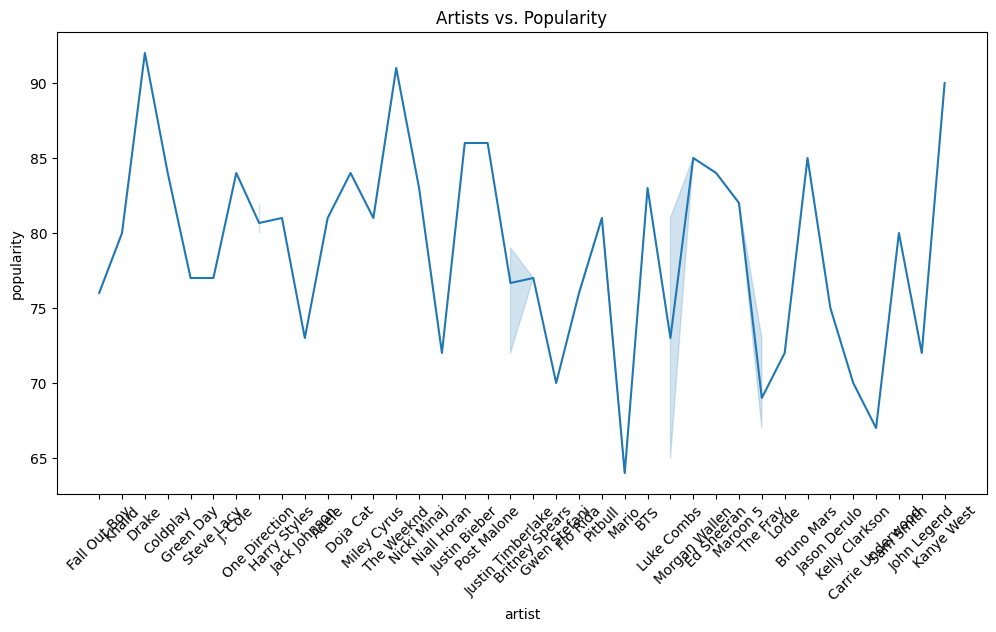

In [ ]:
#This plots the artist to their popularity ranking
import matplotlib.pyplot as plt
import seaborn as sns
#  line plot of artist and their popularity
# Set the size of the figure
plt.figure(figsize=(12, 6))
plt.title('Artists vs. Popularity')
sns.lineplot(data = combined_df, x = 'artist', y = 'popularity')
plt.xticks(rotation=45)
plt.show()

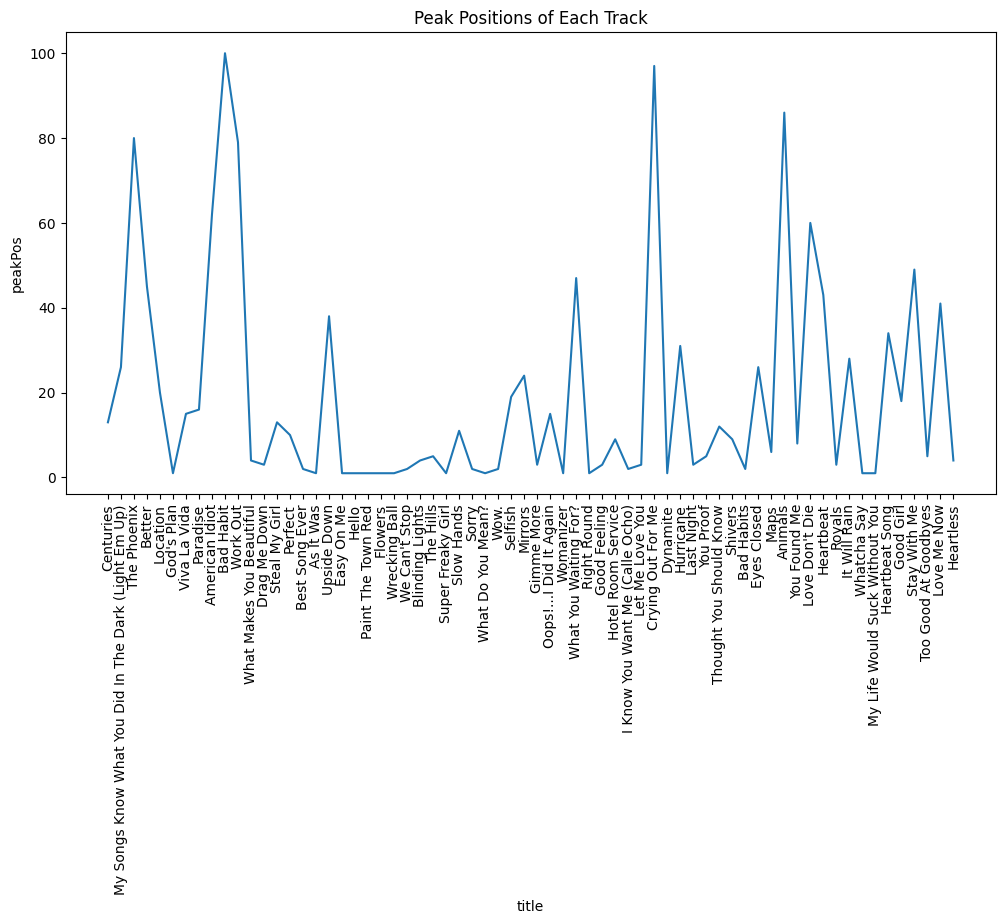

In [ ]:
#This plot shows the peak position of each track that made it onto hot-100
plt.figure(figsize=(12, 6))
plt.title('Peak Positions of Each Track')
sns.lineplot(data = combined_df, x = 'title', y = 'peakPos')
plt.xticks(rotation=90)
plt.show()

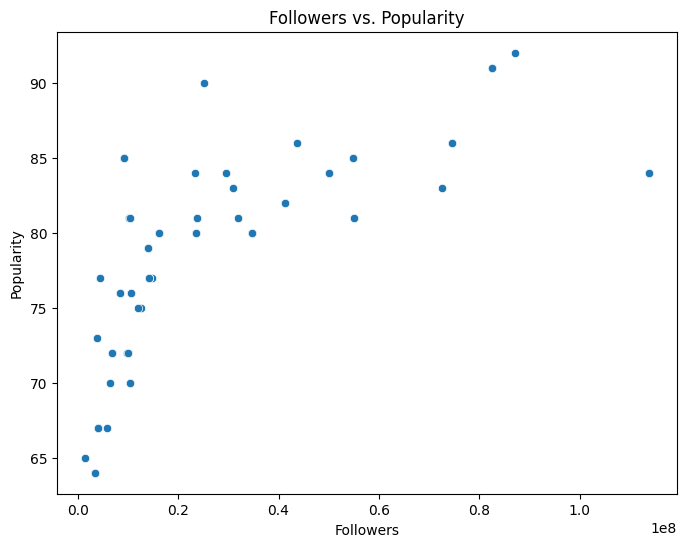

In [ ]:
#this shows the correlation between popularity of an artist and the number of followers they have
plt.figure(figsize=(8, 6))
sns.scatterplot(x='followers', y='popularity', data=combined_df)
plt.title('Followers vs. Popularity')
plt.xlabel('Followers')
plt.ylabel('Popularity')
plt.show()

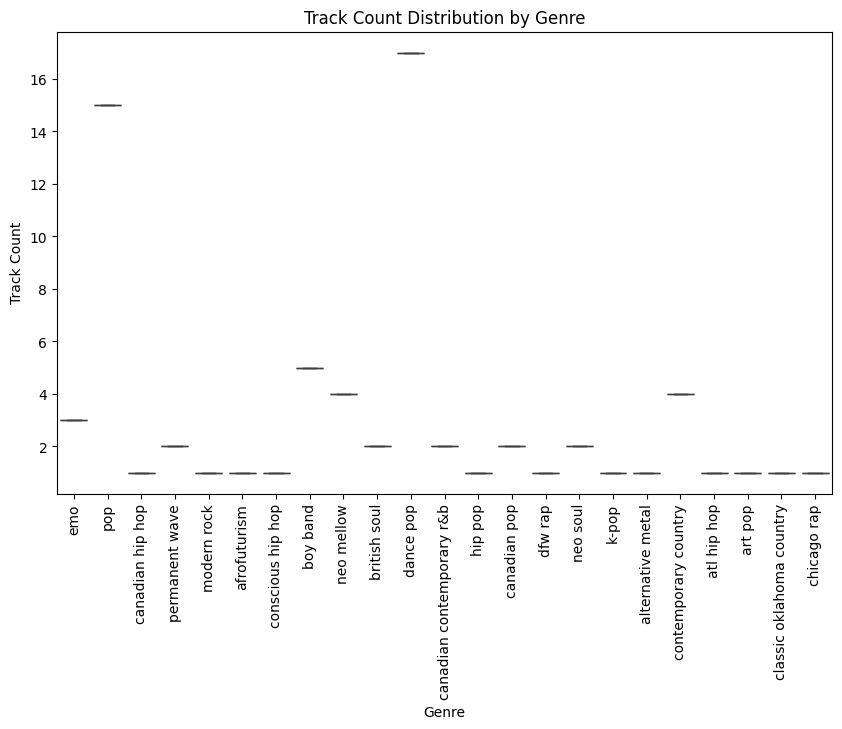

In [ ]:
#This plot shows the number of tracks in each genre that made it on hot-100 from our list of artists
plt.figure(figsize=(10, 6))
sns.boxplot(data=tracks_per_genre_df, x='genre', y='track_count', whis=1.5)
plt.title('Track Count Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Track Count')
plt.xticks(rotation=90)
plt.show()

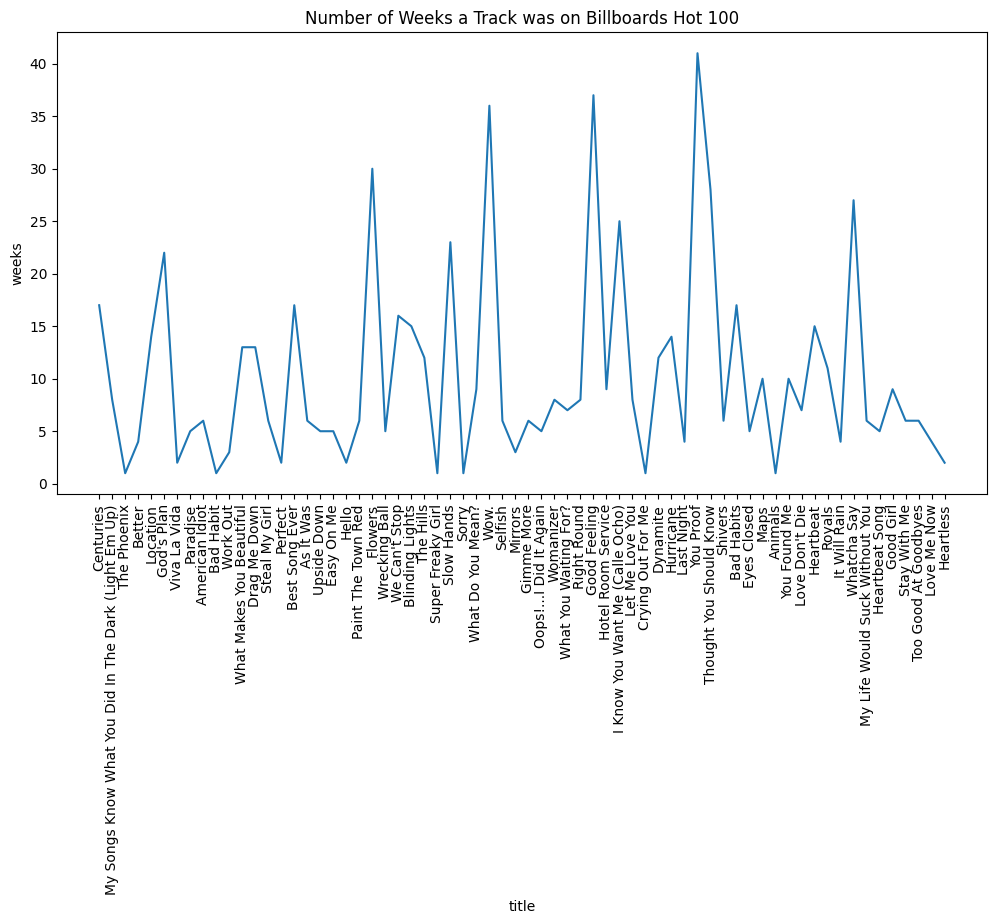

In [ ]:
#This shows the number of weeks a track from our list of artists was on hot-100
plt.figure(figsize=(12, 6))
plt.title('Number of Weeks a Track was on Billboards Hot 100')
sns.lineplot(data = combined_df, x = 'title', y = 'weeks')
plt.xticks(rotation=90)
plt.show()